In [38]:
import nltk
from nltk.corpus import gutenberg

In [39]:
nltk.download('gutenberg')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [40]:
data = gutenberg.raw('shakespeare-hamlet.txt')

In [41]:
words = data.split()
print('total words:',len(words))

total words: 29605


In [42]:
lines = data.split('\n')
print('total lines:\n')
for i in range(20):
  print(lines[i])

total lines:

[The Tragedie of Hamlet by William Shakespeare 1599]


Actus Primus. Scoena Prima.

Enter Barnardo and Francisco two Centinels.

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe

   Bar. Long liue the King

   Fran. Barnardo?
  Bar. He

   Fran. You come most carefully vpon your houre

   Bar. 'Tis now strook twelue, get thee to bed Francisco



In [43]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer

In [44]:
data = data.lower()

In [45]:
data = re.sub(r'[^\w\s]','',data)

In [46]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([data])

In [47]:
word_index = tokenizer.word_index
print('total unique words:' , len(word_index))

total unique words: 4799


In [48]:
input_sequences = []

In [49]:
for line in data.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

In [50]:
print("Total sequences:", len(input_sequences))

Total sequences: 25613


In [51]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [52]:
max_len = max([len(seq) for seq in input_sequences])

input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

In [53]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

In [54]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=len(word_index)+1)

In [55]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (25613, 13)
Shape of y: (25613, 4800)


In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [57]:
model = Sequential()

In [58]:
model.add(Embedding(len(word_index)+1, 100, input_length=max_len-1))
model.add(LSTM(150))
model.add(Dense(len(word_index)+1, activation='softmax'))

In [59]:
model.compile(loss='categorical_crossentropy', optimizer='adam')


In [61]:
history = model.fit(X, y, epochs=20, verbose=1)

Epoch 1/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 6.8399
Epoch 2/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 73s 50ms/step - loss: 6.3835
Epoch 3/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 6.1289
Epoch 4/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - loss: 5.8615
Epoch 5/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - loss: 5.5871
Epoch 6/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 43s 45ms/step - loss: 5.3113
Epoch 7/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 35s 43ms/step - loss: 5.0313
Epoch 8/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - loss: 4.7500
Epoch 9/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - loss: 4.4724
Epoch 10/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - loss: 4.1980
Epoch 11/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - loss: 3.9273
Epoch 12/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - loss: 3.6664
Epoch 13/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - loss: 3.4185
Epoch 14/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - loss: 3.1827
Epoch 15/20
801/801 ━━━━━━━━━

In [62]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 13, 100)        │       480,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4800)           │       724,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,066,202 (15.51 MB)

 Trainable params: 1,355,400 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,710,802 (10.34 MB)

In [63]:
lstm_loss = history.history['loss']

In [76]:
def predict_next_word(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted)

    for word, index in tokenizer.word_index.items():
      if index == predicted_word_index:
        return word


In [80]:
print(predict_next_word("l love my "))
print(predict_next_word("my name "))

father
is


In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

In [71]:
model_gru = Sequential()
model_gru.add(Embedding(len(word_index)+1, 100, input_length=max_len-1))
model_gru.add(GRU(150))
model_gru.add(Dense(len(word_index)+1, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [72]:
model_gru.compile(loss='categorical_crossentropy', optimizer='adam')

In [73]:
history_gru = model_gru.fit(X, y, epochs=20, verbose=1)

Epoch 1/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - loss: 6.8370
Epoch 2/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - loss: 6.1942
Epoch 3/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 5.8074
Epoch 4/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - loss: 5.4043
Epoch 5/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - loss: 4.9758
Epoch 6/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 39s 40ms/step - loss: 4.5403
Epoch 7/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 4.1188
Epoch 8/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 3.7215
Epoch 9/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 3.3613
Epoch 10/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - loss: 3.0378
Epoch 11/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - loss: 2.7561
Epoch 12/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 2.5065
Epoch 13/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 2.2916
Epoch 14/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - loss: 2.0963
Epoch 15/20
801/801 ━━━━━━━━━

In [74]:
gru_loss = history_gru.history['loss']

In [77]:
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 13, 100)        │       480,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 150)            │       113,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4800)           │       724,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,954,602 (15.09 MB)

 Trainable params: 1,318,200 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,636,402 (10.06 MB)

In [79]:
def predict_next_word_gru(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')

    predicted = model_gru.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted)

    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word

In [82]:
print(predict_next_word_gru("my name "))
print(predict_next_word_gru("pain makes "))

is
vow


In [83]:
from tensorflow.keras.layers import SimpleRNN

In [84]:
model_rnn = Sequential()
model_rnn.add(Embedding(len(word_index)+1, 100, input_length=max_len-1))
model_rnn.add(SimpleRNN(150))
model_rnn.add(Dense(len(word_index)+1, activation='softmax'))

In [85]:
model_rnn.compile(loss='categorical_crossentropy', optimizer='adam')

In [87]:
history_rnn = model_rnn.fit(X, y, epochs=20, verbose=1)

Epoch 1/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - loss: 6.8153
Epoch 2/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 6.1939
Epoch 3/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 5.7483
Epoch 4/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 5.2968
Epoch 5/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - loss: 4.8466
Epoch 6/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - loss: 4.4108
Epoch 7/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - loss: 4.0000
Epoch 8/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 3.6227
Epoch 9/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - loss: 3.2790
Epoch 10/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - loss: 2.9727
Epoch 11/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 2.7009
Epoch 12/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - loss: 2.4634
Epoch 13/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - loss: 2.2548
Epoch 14/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 2.0698
Epoch 15/20
801/801 ━━━━━━━━━

In [88]:
model_rnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 13, 100)        │       480,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 150)            │        37,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4800)           │       724,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,727,352 (14.22 MB)

 Trainable params: 1,242,450 (4.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,484,902 (9.48 MB)

In [89]:
rnn_loss = history_rnn.history['loss']

In [90]:
def predict_next_word_rnn(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')

    predicted = model_rnn.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted)

    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word

In [96]:
print(predict_next_word_rnn("what is  "))
print(predict_next_word_rnn("where "))

the
is


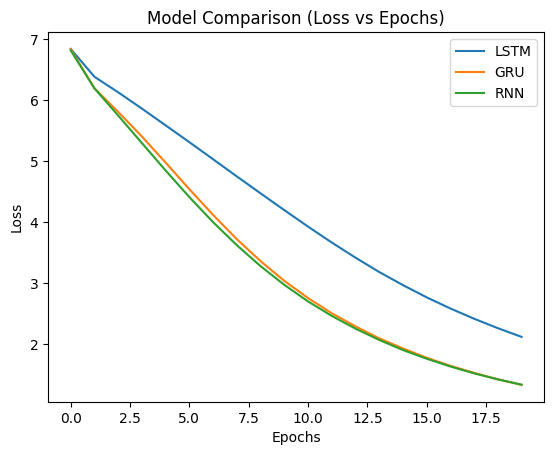

In [97]:
import matplotlib.pyplot as plt

plt.plot(lstm_loss, label='LSTM')
plt.plot(gru_loss, label='GRU')
plt.plot(rnn_loss, label='RNN')

plt.title('Model Comparison (Loss vs Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

From the graph, it is observed that SimpleRNN and GRU achieved lower loss compared to LSTM. This may be due to the simplicity of the dataset and fewer training epochs. While LSTM is designed to capture long-term dependencies, it requires more training time. GRU performed efficiently with faster convergence, while SimpleRNN surprisingly performed well due to short dependency patterns in the dataset.

In [116]:
test_sentences = [
    "where ",
    "i ",
    "what is ",
    "he is",
    "what is"
]

In [117]:
results = []

for sent in test_sentences:
    lstm_pred = predict_next_word(sent)
    gru_pred = predict_next_word_gru(sent)
    rnn_pred = predict_next_word_rnn(sent)

    results.append([sent, lstm_pred, gru_pred, rnn_pred])

In [118]:
df = pd.DataFrame(results, columns=["Input", "LSTM", "GRU", "RNN"])
print("\n🔮 Prediction Comparison:\n")
print(df)



🔮 Prediction Comparison:

      Input  LSTM   GRU     RNN
0    where     it    is  thrift
1        i   haue  haue   alone
2  what is    the   the     the
3     he is  dead  dead   farre
4   what is   the   the     the
